In [1]:
# 📚 Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# ✅ EEG channels (your exact list of 19)
channels = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

# ✅ Class labels assumed to be: AL, MCI, HC
classes = ['AD', 'MCI', 'HC']

# 📂 Load your real and synthetic EEG CSVs (ensure they're in the same directory)
real_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\merged_normalized.csv")
synthetic_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\balanced_dataset1.csv")

# 🔍 Optional: check column names to ensure correctness
print("Columns in real EEG data:", real_df.columns.tolist())
print("Columns in synthetic EEG data:", synthetic_df.columns.tolist())

# Apply min-max normalization only to real data
real_df_norm = real_df.copy()
real_df_norm[channels] = (real_df[channels] - real_df[channels].min()) / (real_df[channels].max() - real_df[channels].min())

# Synthetic data is already normalized — no changes needed

# Compare real (normalized) vs synthetic (already normalized)
results = []

for cls in classes:
    real_class = real_df_norm[real_df_norm['target'] == cls]
    synth_class = synthetic_df[synthetic_df['target'] == cls]

    for ch in channels:
        ks_stat, ks_pval = ks_2samp(real_class[ch], synth_class[ch])
        w_dist = wasserstein_distance(real_class[ch], synth_class[ch])
        interpretation = 'Similar ✅' if ks_pval > 0.05 and w_dist < 0.3 else 'Different ❌'

        results.append({
            'Class': cls,
            'Channel': ch,
            'KS p-value': round(ks_pval, 4),
            'KS Statistic': round(ks_stat, 4),
            'Wasserstein Distance': round(w_dist, 4),
            'Interpretation': interpretation
        })

results_df = pd.DataFrame(results)
display(results_df)

# 💾 Save results to CSV
results_df.to_csv("D:\\RESEARCH 2024\\ALZEIMER II\\classwise_distribution_similarity.csv", index=False)
print("Results saved to D:\\RESEARCH 2024\\ALZEIMER II\\classwise_distribution_similarity.csv")



Columns in real EEG data: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'target']
Columns in synthetic EEG data: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz', 'target']


,Class,Channel,KS p-value,KS Statistic,Wasserstein Distance,Interpretation
0,AD,Fp1,1.0,0.0000,0.0000,Similar ✅
1,AD,Fp2,1.0,0.0000,0.0000,Similar ✅
2,AD,F3,1.0,0.0000,0.0000,Similar ✅
3,AD,F4,1.0,0.0000,0.0000,Similar ✅
4,AD,C3,1.0,0.0000,0.0000,Similar ✅
5,AD,C4,1.0,0.0000,0.0000,Similar ✅
6,AD,P3,1.0,0.0000,0.0000,Similar ✅
7,AD,P4,1.0,0.0000,0.0000,Similar ✅
8,AD,O1,1.0,0.0000,0.0000,Similar ✅
9,AD,O2,1.0,0.0000,0.0000,Similar ✅


Results saved to D:\RESEARCH 2024\ALZEIMER II\classwise_distribution_similarity.csv


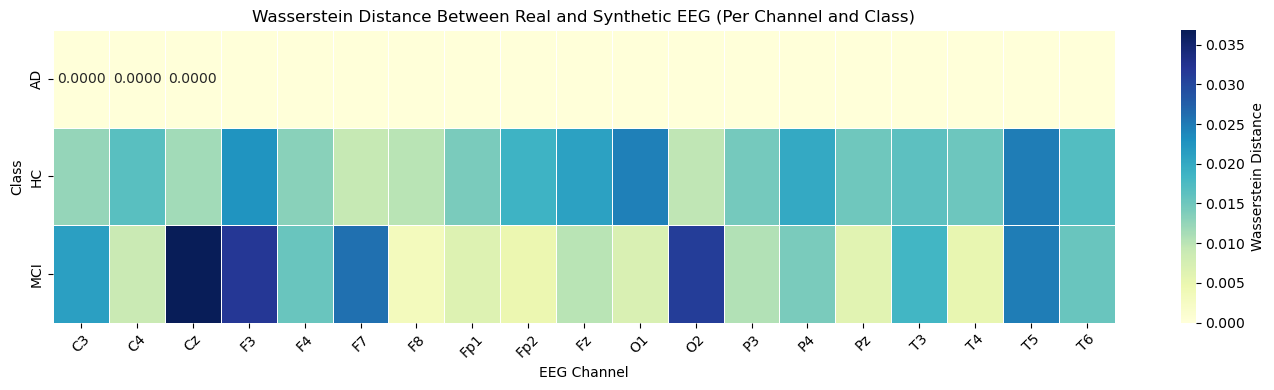

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the filtered CSV file (excluding AL class)
# Make sure this file has columns: 'Class', 'Channel', 'Wasserstein Distance'
df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\classwise_distribution_similarity.csv")

# Pivot the data: rows = Class (MCI, HC), columns = EEG Channels, values = Wasserstein distances
heatmap_data = df.pivot(index="Class", columns="Channel", values="Wasserstein Distance")

# Plot the heatmap
plt.figure(figsize=(14, 4))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f",
    linewidths=0.5,
    cbar_kws={"label": "Wasserstein Distance"}
)
plt.title("Wasserstein Distance Between Real and Synthetic EEG (Per Channel and Class)")
plt.xlabel("EEG Channel")
plt.ylabel("Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


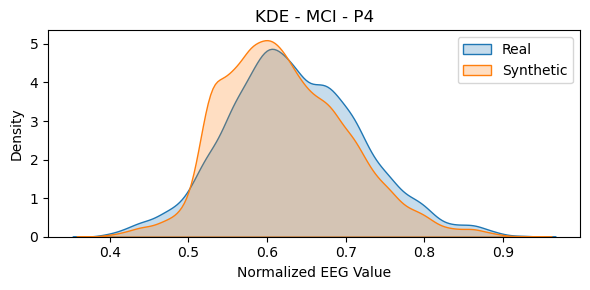

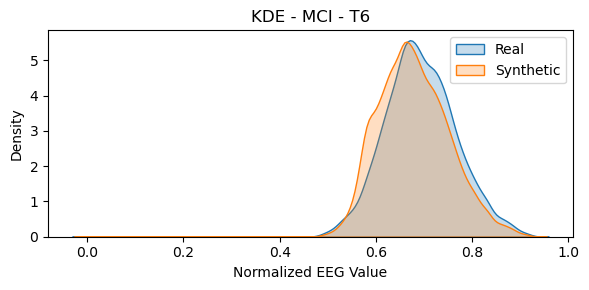

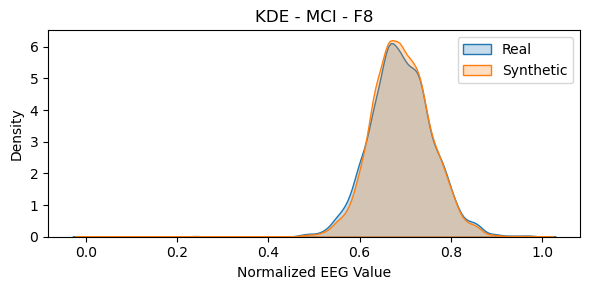

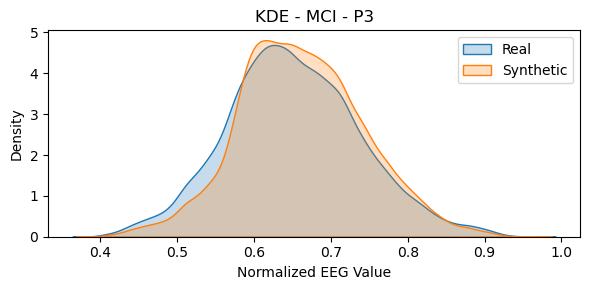

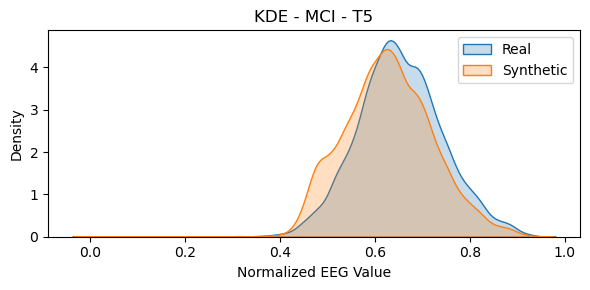

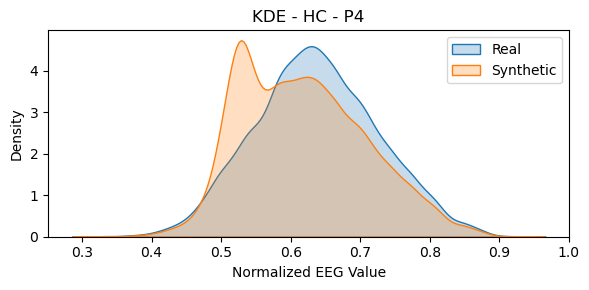

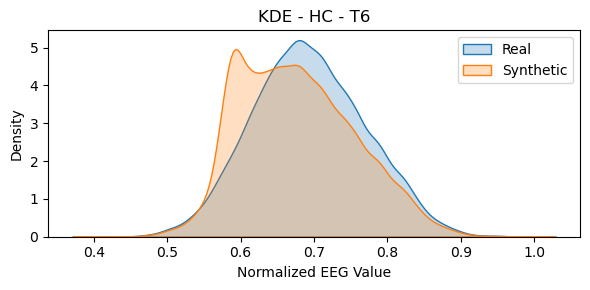

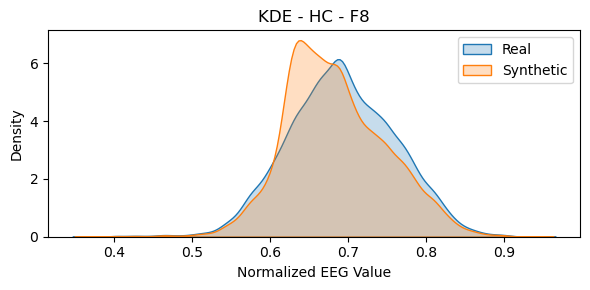

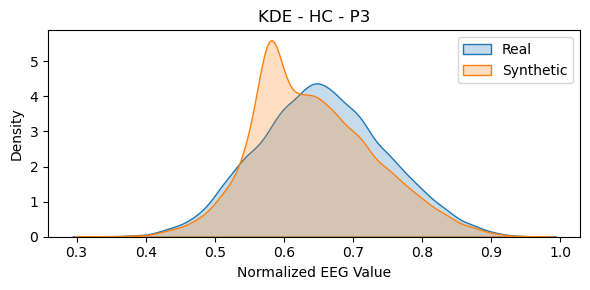

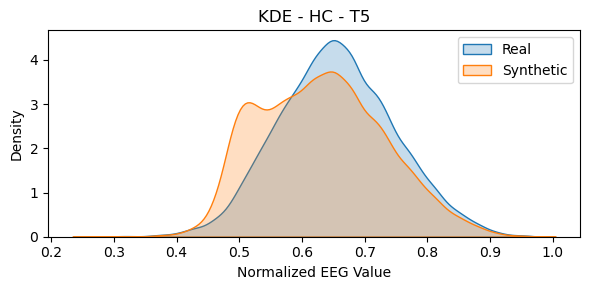

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your real and synthetic DataFrames
real_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\merged_normalized.csv")
synthetic_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\balanced_dataset1.csv")

# Define channels to compare
mci_best_channels = ['P3', 'O1', 'Fz', 'F8']
hc_best_channels = ['F4', 'F3', 'Fp2', 'F7']


# Apply min-max normalization only to real data
real_df_norm = real_df.copy()
real_df_norm[channels] = (real_df[channels] - real_df[channels].min()) / (real_df[channels].max() - real_df[channels].min())


# Function to plot KDE for each channel and class
def plot_kde_comparison(real_df_norm, synthetic_df, channels, target_class):
    real_class = real_df_norm[real_df['target'] == target_class]
    synth_class = synthetic_df[synthetic_df['target'] == target_class]

    for ch in channels:
        plt.figure(figsize=(6, 3))
        sns.kdeplot(real_class[ch], label='Real', fill=True)
        sns.kdeplot(synth_class[ch], label='Synthetic', fill=True)
        plt.title(f'KDE - {target_class} - {ch}')
        plt.xlabel('Normalized EEG Value')
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()

# Plot KDEs for both classes
for cls in classes:
    plot_kde_comparison(real_df_norm, synthetic_df, channels, target_class=cls)


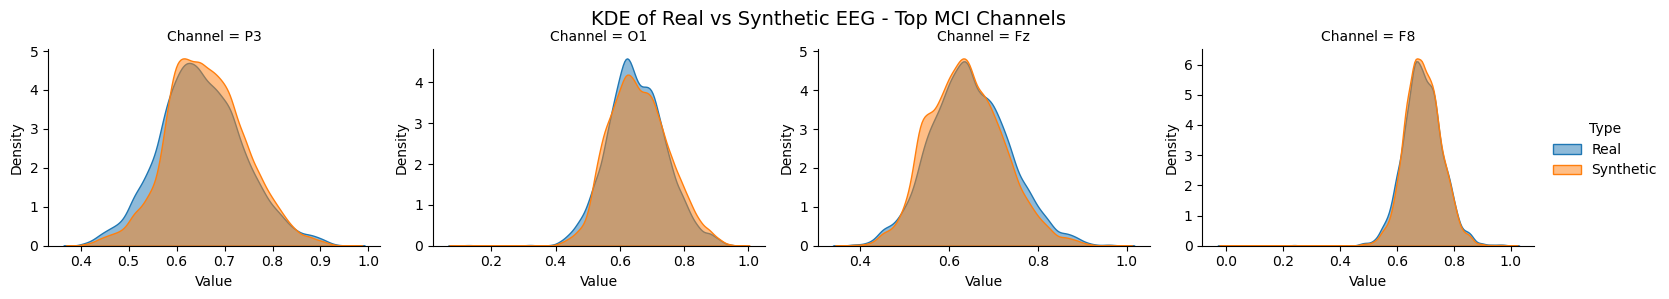

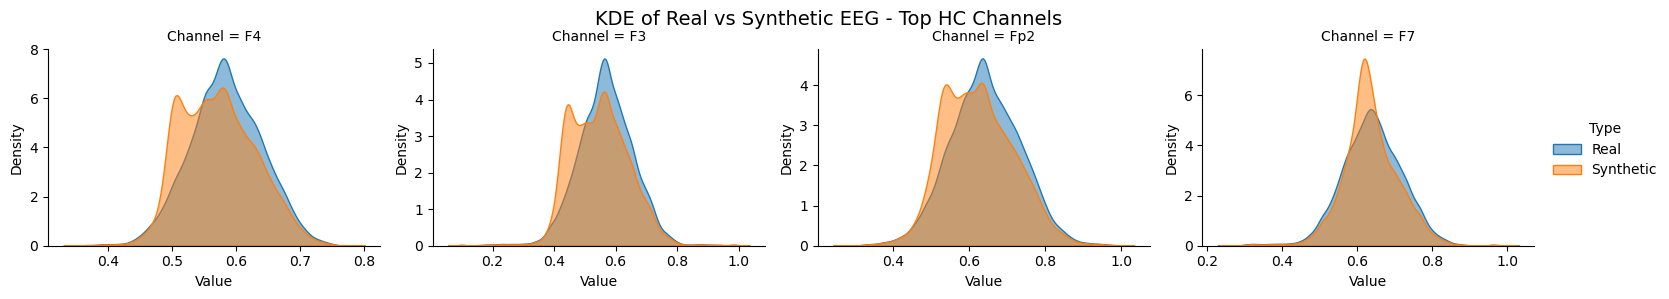

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define best channels
mci_best_channels = ['P3', 'O1', 'Fz', 'F8']
hc_best_channels = ['F4', 'F3', 'Fp2', 'F7']

# Load datasets
real_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\merged_normalized.csv")
synthetic_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\balanced_dataset1.csv")

# Tag type
real_df['Type'] = 'Real'
synthetic_df['Type'] = 'Synthetic'

# Combine
df = pd.concat([real_df, synthetic_df], ignore_index=True)

# Filter MCI and HC
df = df[df['target'].isin(['MCI', 'HC'])]

# Separate plotting for MCI
mci_df = df[df['target'] == 'MCI']
mci_melted = pd.melt(mci_df, id_vars=['target', 'Type'], value_vars=mci_best_channels,
                     var_name='Channel', value_name='Value')

g1 = sns.FacetGrid(mci_melted, col="Channel", hue="Type", sharex=False, sharey=False, height=3, aspect=1.3)
g1.map(sns.kdeplot, "Value", fill=True, alpha=0.5)
g1.add_legend()
g1.fig.subplots_adjust(top=0.85)
g1.fig.suptitle("KDE of Real vs Synthetic EEG - Top MCI Channels", fontsize=14)

# Separate plotting for HC
hc_df = df[df['target'] == 'HC']
hc_melted = pd.melt(hc_df, id_vars=['target', 'Type'], value_vars=hc_best_channels,
                    var_name='Channel', value_name='Value')

g2 = sns.FacetGrid(hc_melted, col="Channel", hue="Type", sharex=False, sharey=False, height=3, aspect=1.3)
g2.map(sns.kdeplot, "Value", fill=True, alpha=0.5)
g2.add_legend()
g2.fig.subplots_adjust(top=0.85)
g2.fig.suptitle("KDE of Real vs Synthetic EEG - Top HC Channels", fontsize=14)

plt.show()


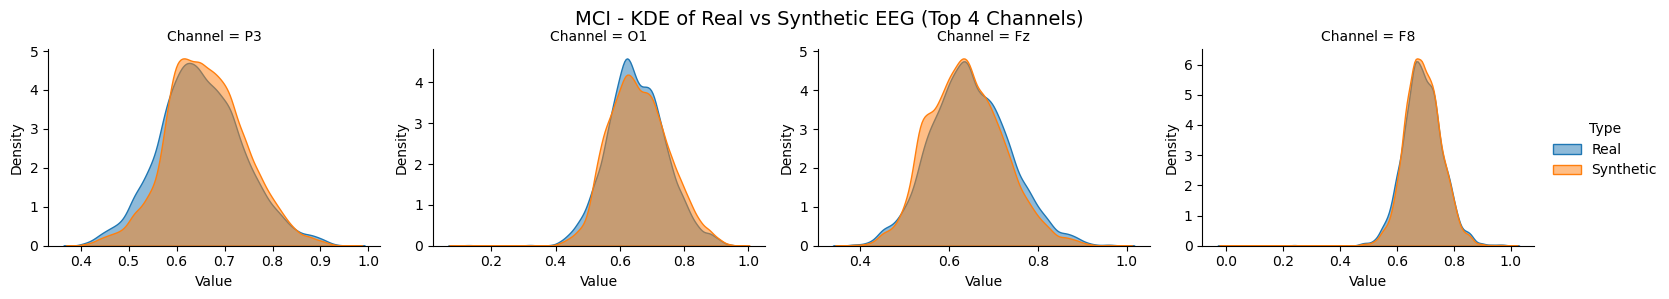

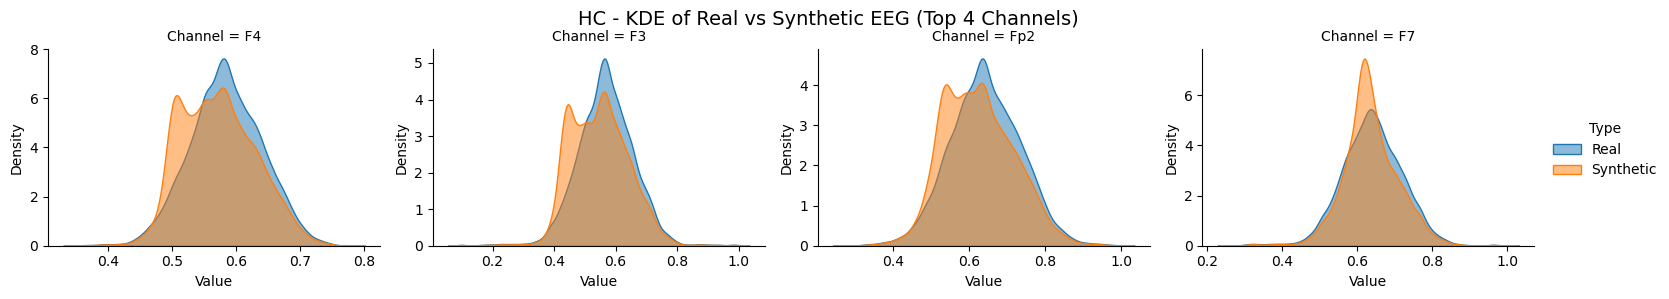

In [7]:
############## AL DATASET II ######################


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define best channels
mci_best_channels = ['P3', 'O1', 'Fz', 'F8']
hc_best_channels = ['F4', 'F3', 'Fp2', 'F7']

# Load datasets
real_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\merged_normalized.csv")
synthetic_df = pd.read_csv("D:\\RESEARCH 2024\\ALZEIMER II\\balanced_dataset1.csv")

# Tag type
real_df['Type'] = 'Real'
synthetic_df['Type'] = 'Synthetic'

# Combine
df = pd.concat([real_df, synthetic_df], ignore_index=True)

# Filter MCI and HC
df = df[df['target'].isin(['MCI', 'HC'])]

# --- Plot for MCI ---
mci_df = df[df['target'] == 'MCI']
mci_melted = pd.melt(mci_df, id_vars=['target', 'Type'], value_vars=mci_best_channels,
                     var_name='Channel', value_name='Value')

g1 = sns.FacetGrid(mci_melted, col="Channel", hue="Type", sharex=False, sharey=False, height=3, aspect=1.3)
g1.map(sns.kdeplot, "Value", fill=True, alpha=0.5)
g1.add_legend()
g1.fig.subplots_adjust(top=0.85)
g1.fig.suptitle("MCI - KDE of Real vs Synthetic EEG (Top 4 Channels)", fontsize=14)

# --- Plot for HC ---
hc_df = df[df['target'] == 'HC']
hc_melted = pd.melt(hc_df, id_vars=['target', 'Type'], value_vars=hc_best_channels,
                    var_name='Channel', value_name='Value')

g2 = sns.FacetGrid(hc_melted, col="Channel", hue="Type", sharex=False, sharey=False, height=3, aspect=1.3)
g2.map(sns.kdeplot, "Value", fill=True, alpha=0.5)
g2.add_legend()
g2.fig.subplots_adjust(top=0.85)
g2.fig.suptitle("HC - KDE of Real vs Synthetic EEG (Top 4 Channels)", fontsize=14)

plt.show()


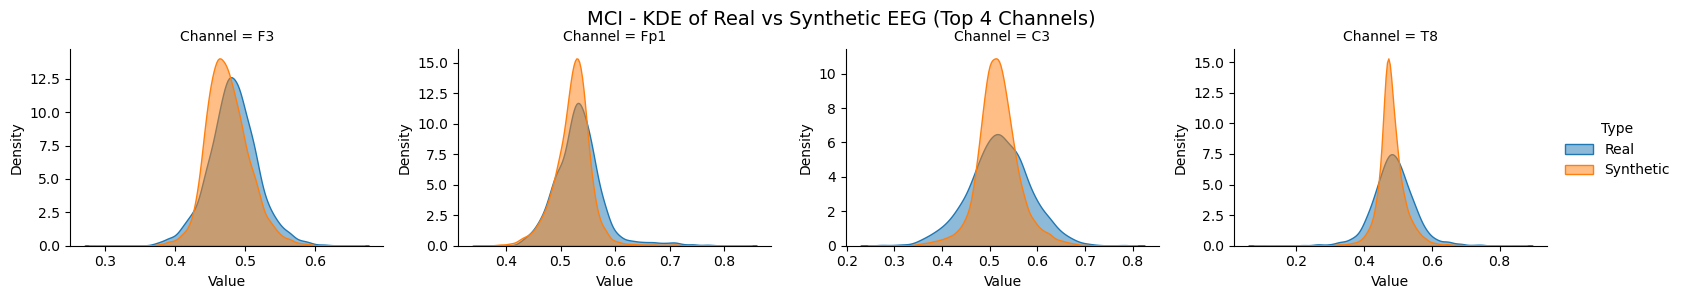

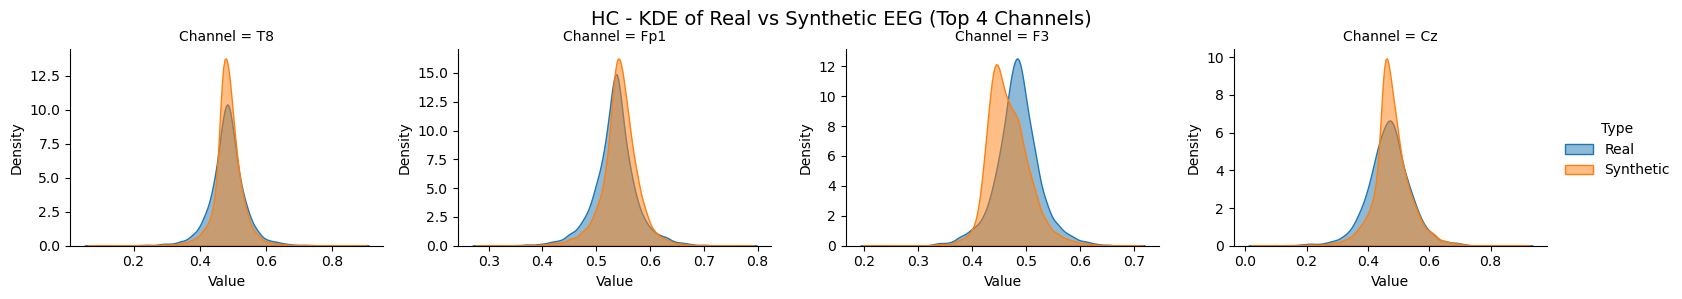

In [8]:
############## AL DATASET 40Hz ######################


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define best channels
mci_best_channels = ['F3', 'Fp1' , 'C3' , 'T8'] 
hc_best_channels = ['T8' , 'Fp1', 'F3' , 'Cz']

# Load datasets
real_df = pd.read_csv("D:\\RESEARCH 2024\\40Hz ALZIEMER 2024\\PROCESSED DATA\\merged_normalized.csv")
synthetic_df = pd.read_csv("D:\\RESEARCH 2024\\40Hz ALZIEMER 2024\\PROCESSED DATA\\balanced_dataset1.csv")

# Tag type
real_df['Type'] = 'Real'
synthetic_df['Type'] = 'Synthetic'

# Combine
df = pd.concat([real_df, synthetic_df], ignore_index=True)

# Filter MCI and HC
df = df[df['target'].isin(['MCI', 'HC'])]

# --- Plot for MCI ---
mci_df = df[df['target'] == 'MCI']
mci_melted = pd.melt(mci_df, id_vars=['target', 'Type'], value_vars=mci_best_channels,
                     var_name='Channel', value_name='Value')

g1 = sns.FacetGrid(mci_melted, col="Channel", hue="Type", sharex=False, sharey=False, height=3, aspect=1.3)
g1.map(sns.kdeplot, "Value", fill=True, alpha=0.5)
g1.add_legend()
g1.fig.subplots_adjust(top=0.85)
g1.fig.suptitle("MCI - KDE of Real vs Synthetic EEG (Top 4 Channels)", fontsize=14)

# --- Plot for HC ---
hc_df = df[df['target'] == 'HC']
hc_melted = pd.melt(hc_df, id_vars=['target', 'Type'], value_vars=hc_best_channels,
                    var_name='Channel', value_name='Value')

g2 = sns.FacetGrid(hc_melted, col="Channel", hue="Type", sharex=False, sharey=False, height=3, aspect=1.3)
g2.map(sns.kdeplot, "Value", fill=True, alpha=0.5)
g2.add_legend()
g2.fig.subplots_adjust(top=0.85)
g2.fig.suptitle("HC - KDE of Real vs Synthetic EEG (Top 4 Channels)", fontsize=14)

plt.show()
